<a href="https://colab.research.google.com/github/Phil1263/Group-4-CNN-Image-Classification/blob/main/Model_12_(86.5%25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.




In [1]:
from keras.backend import clear_session
clear_session()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
#
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


# Transfer learning

In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Resize and convert to numpy float32
x_train_resized = tf.image.resize(x_train, (96, 96)).numpy().astype("float32")
x_test_resized = tf.image.resize(x_test, (96, 96)).numpy().astype("float32")

# Apply MobileNetV2 preprocessing
x_train_preprocessed = preprocess_input(x_train_resized)
x_test_preprocessed = preprocess_input(x_test_resized)

print(x_train_preprocessed.shape, x_train_preprocessed.dtype)
print(x_test_preprocessed.shape, x_test_preprocessed.dtype)

(50000, 96, 96, 3) float32
(10000, 96, 96, 3) float32


In [4]:
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model_mobilenet = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model_mobilenet.trainable = False

model_mobilenet = models.Sequential([
    base_model_mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Compile
model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Convert labels to one-hot encoded format
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Train
history_mobilenet = model_mobilenet.fit(
    x_train_preprocessed,
    y_train,
    epochs=15,
    batch_size=16, # Reduced batch size
    validation_split=0.2,
)

Epoch 1/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.7649 - loss: 0.7277 - val_accuracy: 0.8514 - val_loss: 0.4249
Epoch 2/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8138 - loss: 0.5588 - val_accuracy: 0.8606 - val_loss: 0.4105
Epoch 3/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8235 - loss: 0.5197 - val_accuracy: 0.8613 - val_loss: 0.3988
Epoch 4/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8335 - loss: 0.4927 - val_accuracy: 0.8640 - val_loss: 0.4058
Epoch 5/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.8382 - loss: 0.4763 - val_accuracy: 0.8656 - val_loss: 0.3988
Epoch 6/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8443 - loss: 0.4588 - val_accuracy: 0.8634 - val_loss: 0.4079
Epoch 7/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8502 - loss: 0.4380 - val_accuracy: 0.8668 - val_loss: 0.4007
Epoch 8/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8534 - loss: 

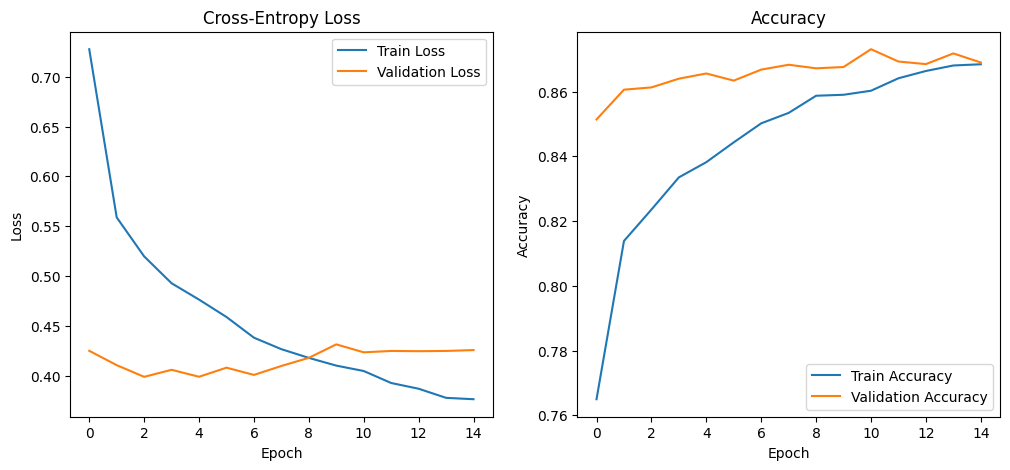

In [6]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [7]:
test_loss, test_accuracy = model_mobilenet.evaluate(x_test_preprocessed, y_test)
print("Test Accuracy for MobileNet:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8622 - loss: 0.4424
Test Accuracy for MobileNet: 0.8622000217437744


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step


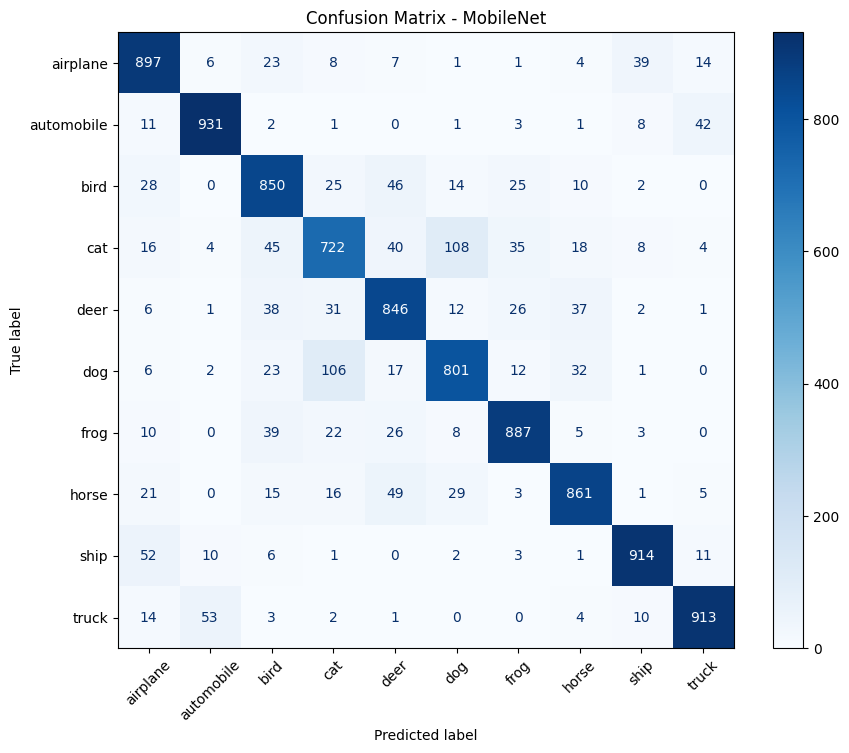

airplane is most confused with ship (39 times)
automobile is most confused with truck (42 times)
bird is most confused with deer (46 times)
cat is most confused with dog (108 times)
deer is most confused with bird (38 times)
dog is most confused with cat (106 times)
frog is most confused with bird (39 times)
horse is most confused with deer (49 times)
ship is most confused with airplane (52 times)
truck is most confused with automobile (53 times)


In [8]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Predictions from MobileNet model
y_pred = model_mobilenet.predict(x_test_preprocessed)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix - MobileNet")
plt.xticks(rotation=45)
plt.show()

# Show the main confusion for each class
for i in range(len(classes)):
    row = cm[i].copy()
    row[i] = 0
    most_confused_with = np.argmax(row)

    print(f"{classes[i]} is most confused with {classes[most_confused_with]} ({row[most_confused_with]} times)")

In [9]:
# Save the model
model_mobilenet.save("model_mobilenet1.keras")